In [42]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import torch 
from torch.utils.data import DataLoader

from neuralhydrology.modelzoo.ealstm import EALSTM
from neuralhydrology.utils.config import Config
from neuralhydrology.datasetzoo import get_dataset
from neuralhydrology.datautils.utils import load_scaler
from neuralhydrology.evaluation import get_tester


In [28]:
run_dir = Path("/home/wuhlmann/BA/repo/lamah-ce_lstm/models/q_pred_landcover_0903_135428")
cfg = Config(run_dir / "config.yml")
# Initialize model with base paramters from config. 
ea_lstm = EALSTM(cfg=cfg)

# Load the trained weights into the model. 
weights_path = run_dir / f"model_epoch016.pt"
weights = torch.load(str(weights_path), map_location="cpu")
ea_lstm.load_state_dict(weights)


<All keys matched successfully>

In [29]:
sum(p.numel() for p in ea_lstm.parameters() if p.requires_grad) 

206849

In [30]:
state_dict = ea_lstm.state_dict()

### Inspect $i$

In [31]:
attributes = [
	#geomorph - unargueable
	"area_calc", # how much water is available *
	"elev_mean", # how much snow, how much energy *
	"elev_ran", # how variable is the catchment
	"slope_mean", # energy of surface runoff *(since mountains)

	#precipitation
	"p_mean", # influx *
	"et0_mean", # outflux *
	"arid_1", # there are some arid catchments (more et0 than p_mean)
	"p_season", # encode seasonal pattern *
	"hi_prec_fr", # how often do high prec events occur (days/yr with p > 5*p_mean) *
	"hi_prec_du", #*
	"lo_prec_fr", # how often do low prec events occur (days/yr with p < 1 mm/d) *
	"lo_prec_du", #*
	"frac_snow", # essential in mountainous catchments *

    #land cover - nice, since they are accurate over the catchment, and not averaged
	"agr_fra", # 
	"bare_fra", # 
	"forest_fra", # storage
	"glac_fra", # super rare case, and then not that important 
	"lake_fra", # storage, also quite rare
	"urban_fra", # * versieglung, an proxy for disturbance of natural waterways

	#vegetation - represent water storage, and also differences between summer and winter - choose lai or ndvi, since they are correlated. And lai also has some info, about how many layers of vegetation there are. 
	"lai_max", 
	"lai_diff",
	"gvf_max",
	"gvf_diff",

	#soil - represent storage and also percolation speed
	"bedrk_dep", #*
	"soil_poros", #*
	"soil_condu", #*
	"sand_fra", #*
	"silt_fra", #*
	"clay_fra" #*
	]

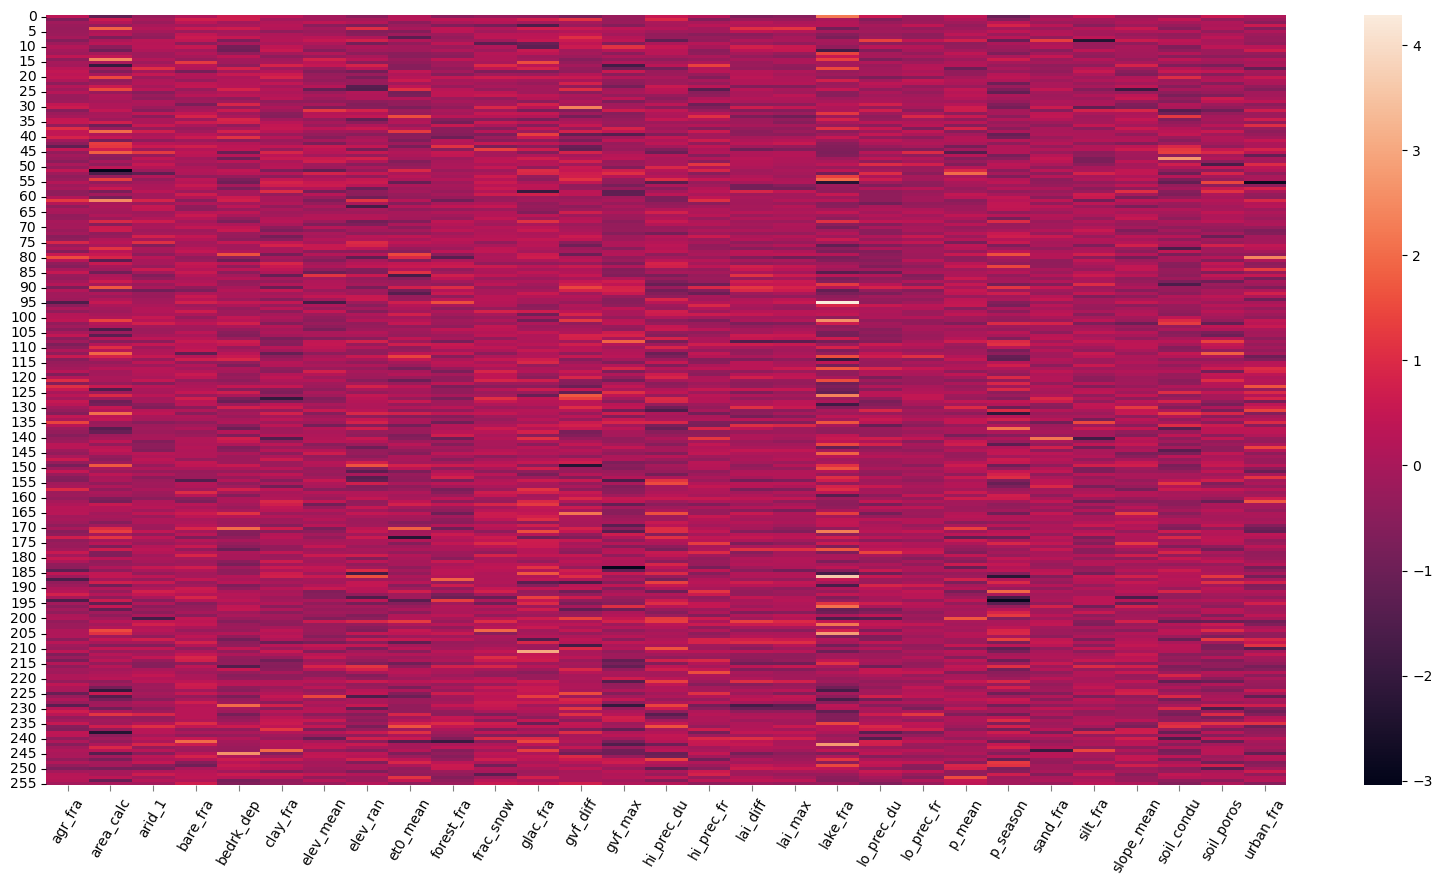

In [44]:
fig, ax = plt.subplots(1,1, figsize=(20,10))
i_weights = ea_lstm.input_gate.weight.detach().numpy()
i_weights_df = pd.DataFrame(data=i_weights, columns=sorted(attributes))
sns.heatmap(i_weights_df, ax=ax)
ax.tick_params(axis='x', length=4, color="gray", labelrotation=60) 
    

In [70]:
i_weights_df.loc[235].nlargest(5)

lake_fra      1.433230
soil_poros    1.165425
urban_fra     1.111131
bare_fra      1.009849
forest_fra    0.980837
Name: 235, dtype: float32

In [33]:
import pandas as pd

attr_abs_mean_weight = pd.DataFrame(data =abs(i_weights).mean(axis=0), index=sorted(attributes))

In [34]:
attr_abs_mean_weight.sort_values(by=0, ascending=False)

,0
lake_fra,0.639572
area_calc,0.512117
p_season,0.506889
gvf_diff,0.452231
glac_fra,0.447851
hi_prec_du,0.443307
elev_ran,0.438892
gvf_max,0.429247
soil_condu,0.426120
urban_fra,0.403718


In [35]:
import pickle as pkl

with open("/home/wuhlmann/BA/data/processed_data/evaluation/input_gate.p", "rb") as f: 
    input_gate_dict = pkl.load(f)

input_gate_dict = dict(sorted(input_gate_dict.items(), key=lambda item: int(item[0])))


In [36]:
i_vectors = []

for b in input_gate_dict.keys():

	i_vectors.append(torch.sigmoid(torch.tensor(input_gate_dict[b])).detach().numpy())

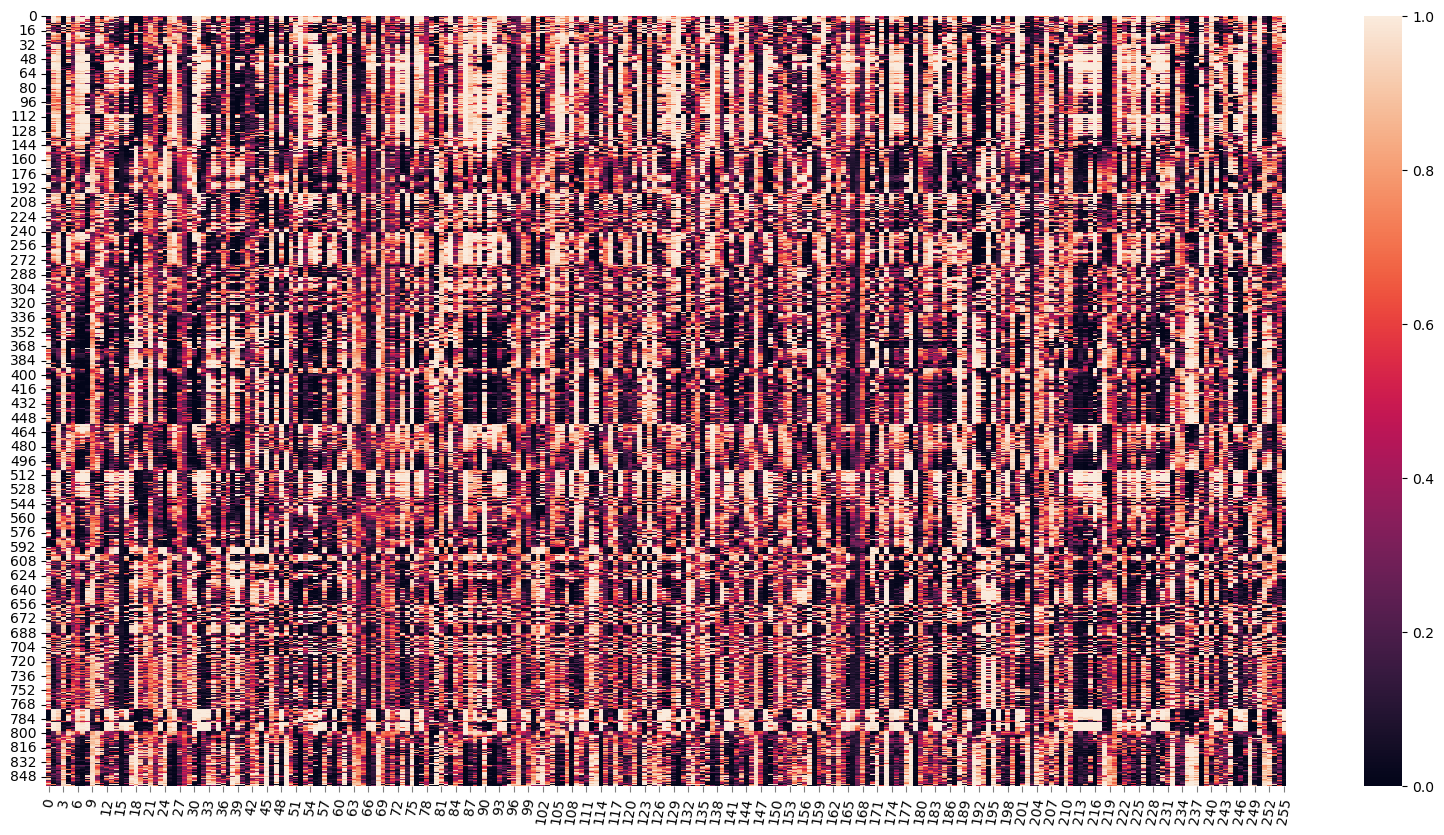

In [37]:
fig, ax = plt.subplots(1,1, figsize=(20,10))
sns.heatmap(i_vectors, ax=ax)
ax.tick_params(axis='x', length=4, color="gray", labelrotation=80) 

In [38]:
import pandas as pd
import geopandas as gpd

strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["0"]
lamah_gdf.sort_index(ascending=True, inplace=True)

<Axes: >

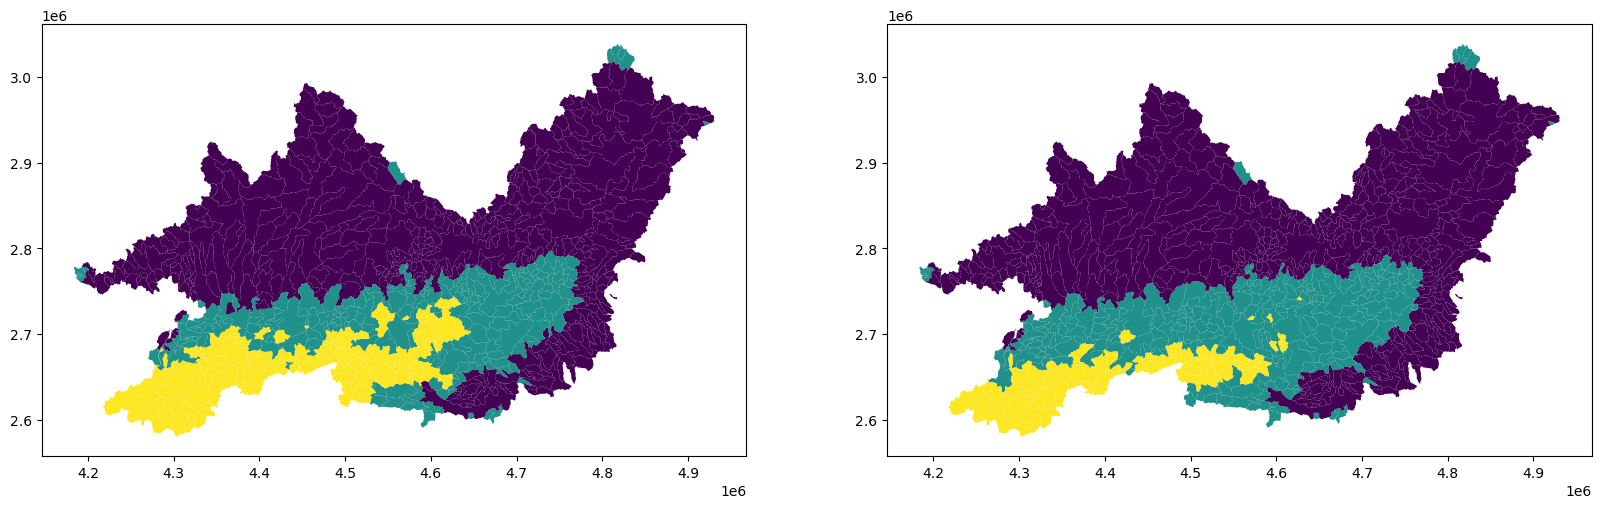

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(3, random_state=1277)

labels = kmeans.fit_predict(i_vectors)

label_remap = {
    0: 1,
    1: 0, 
    2: 2
}

labels = list(map(lambda x: label_remap[x], labels))


fig, axs = plt.subplots(1,2, figsize=(20,10))

lamah_gdf["cluster"] = labels
lamah_gdf.plot("cluster", ax=axs[0])
lamah_gdf.plot("strata", ax=axs[1])